In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import urllib.request

url = "https://raw.githubusercontent.com/tasnim202/data-science-project/main/testcases.py"
urllib.request.urlretrieve(url, "testcases.py")

url = "https://raw.githubusercontent.com/tasnim202/data-science-project/refs/heads/main/hour.csv"

In [115]:
df = pd.read_csv(url)
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [116]:
df.shape, df.columns

((17379, 17),
 Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
        'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
        'casual', 'registered', 'cnt'],
       dtype='object'))

In [117]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [118]:
df.describe()


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [119]:
df.isna().sum()


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [120]:
df.duplicated().sum()


np.int64(0)

In [121]:
df["cnt"].describe()


,cnt
count,17379.000000
mean,189.463088
std,181.387599
min,1.000000
25%,40.000000
50%,142.000000
75%,281.000000
max,977.000000


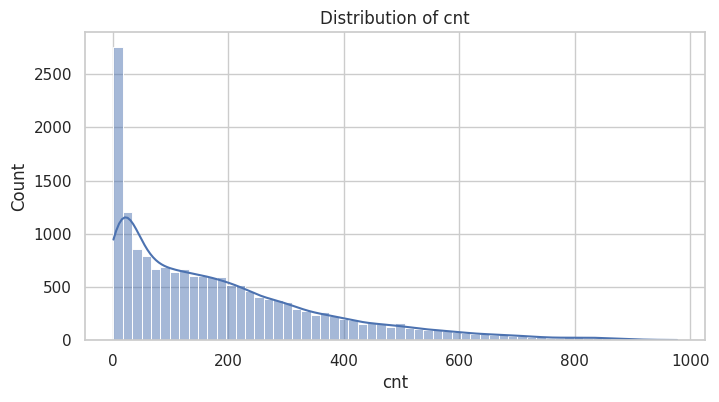

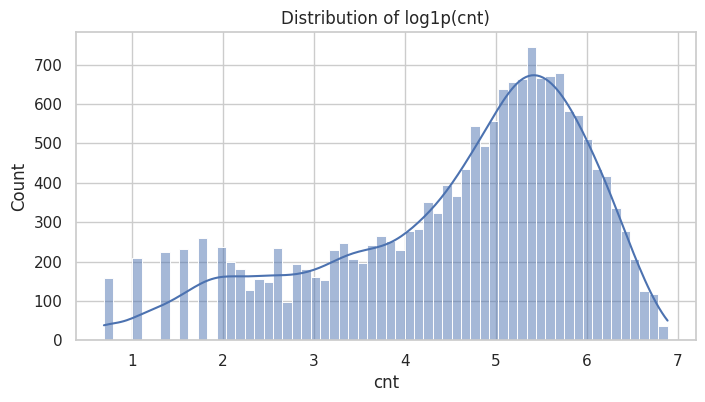

In [122]:


sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,4))
sns.histplot(df["cnt"], bins=60, kde=True)
plt.title("Distribution of cnt")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(np.log1p(df["cnt"]), bins=60, kde=True)
plt.title("Distribution of log1p(cnt)")
plt.show()


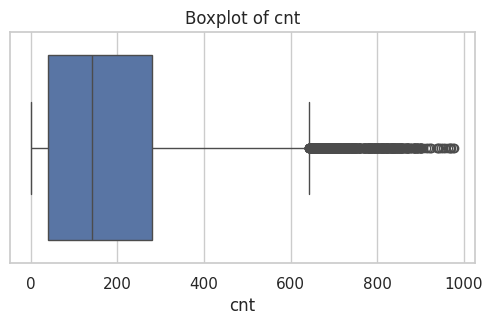

In [123]:
plt.figure(figsize=(6,3))
sns.boxplot(x=df["cnt"])
plt.title("Boxplot of cnt")
plt.show()


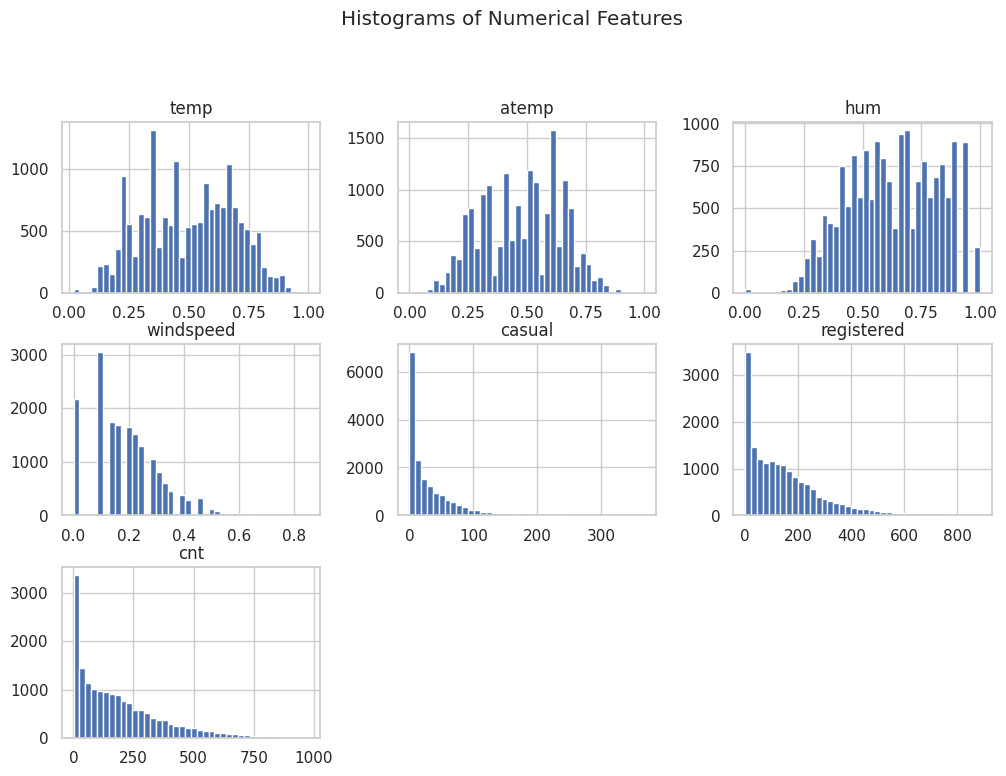

In [124]:
num_cols = ["temp","atemp","hum","windspeed","casual","registered","cnt"]
df[num_cols].hist(figsize=(12,8), bins=40)
plt.suptitle("Histograms of Numerical Features", y=1.02)
plt.show()


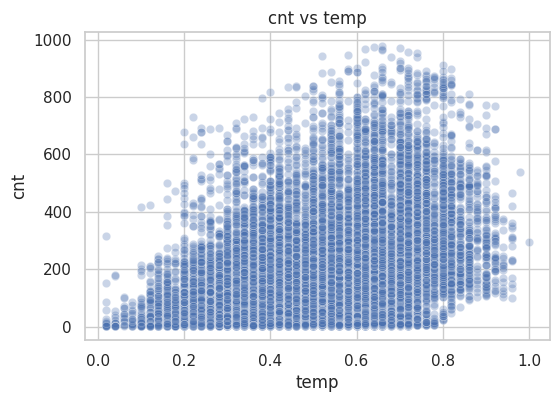

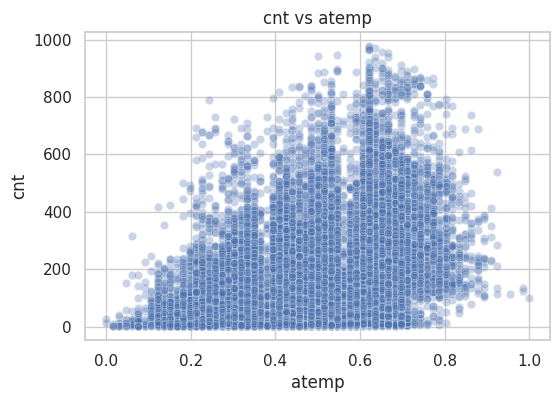

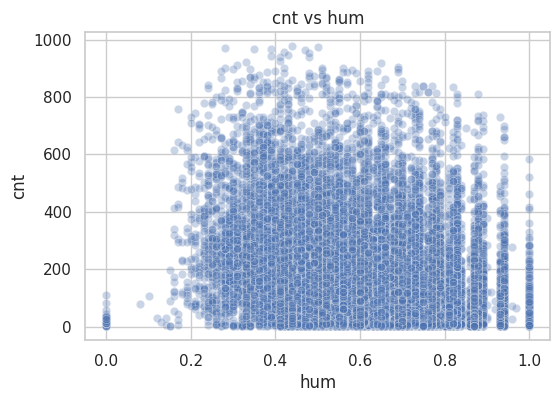

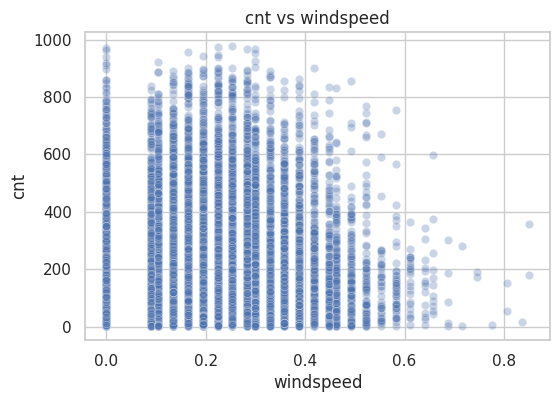

In [125]:
for c in ["temp","atemp","hum","windspeed"]:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=c, y="cnt", alpha=0.3)
    plt.title(f"cnt vs {c}")
    plt.show()


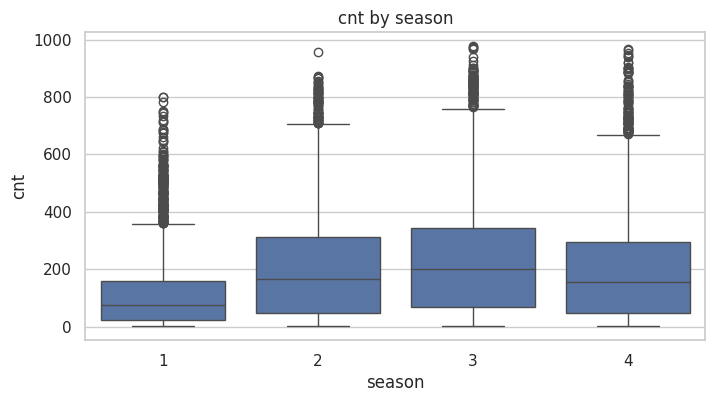

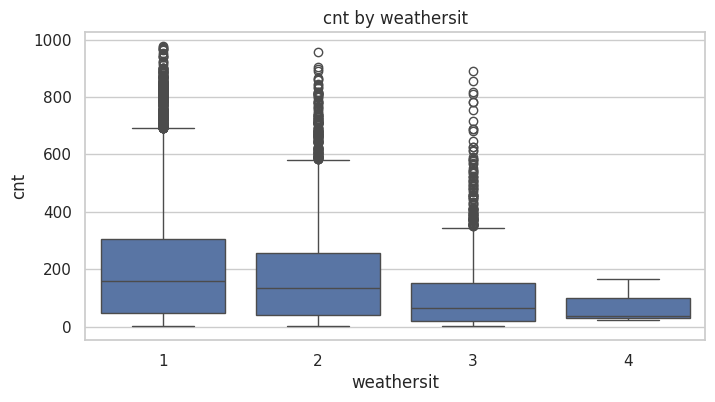

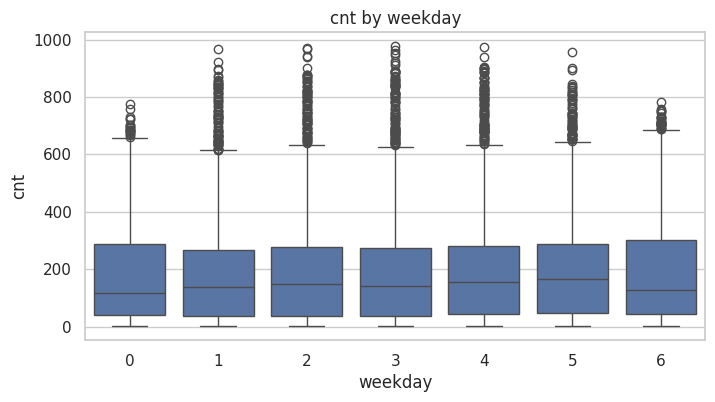

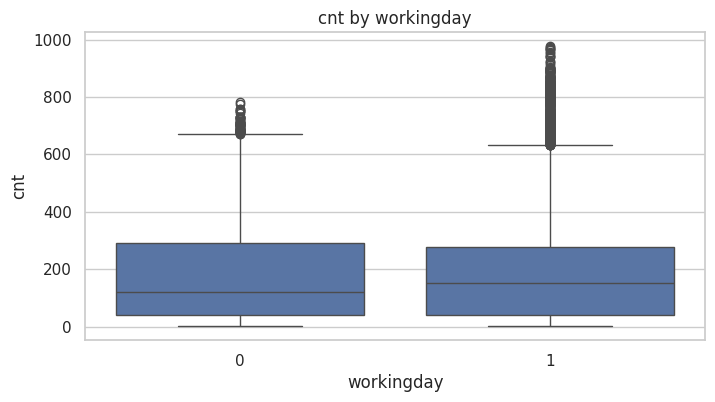

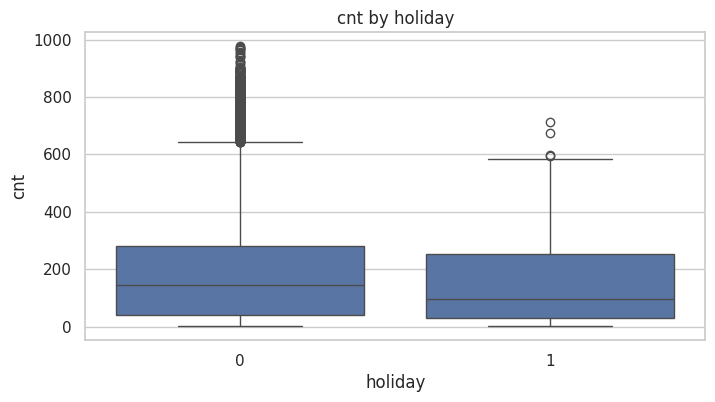

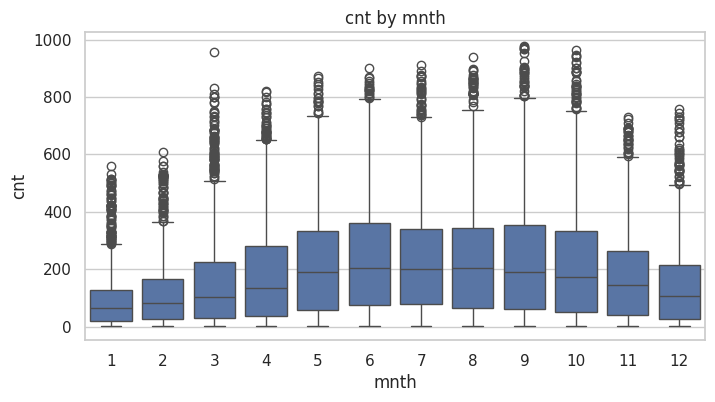

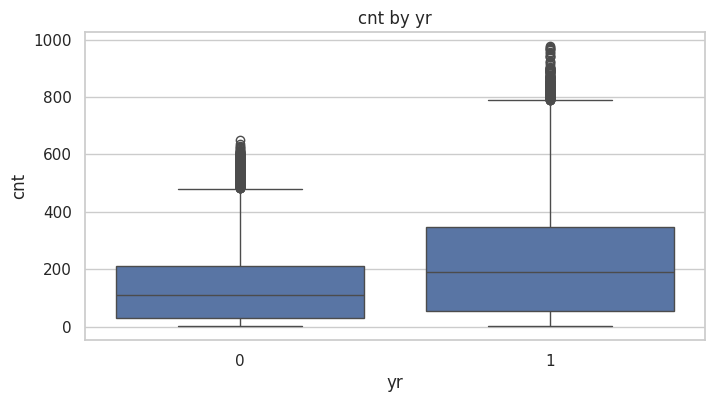

In [126]:
cat_cols = ["season","weathersit","weekday","workingday","holiday","mnth","yr"]
for c in cat_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x=c, y="cnt")
    plt.title(f"cnt by {c}")
    plt.show()


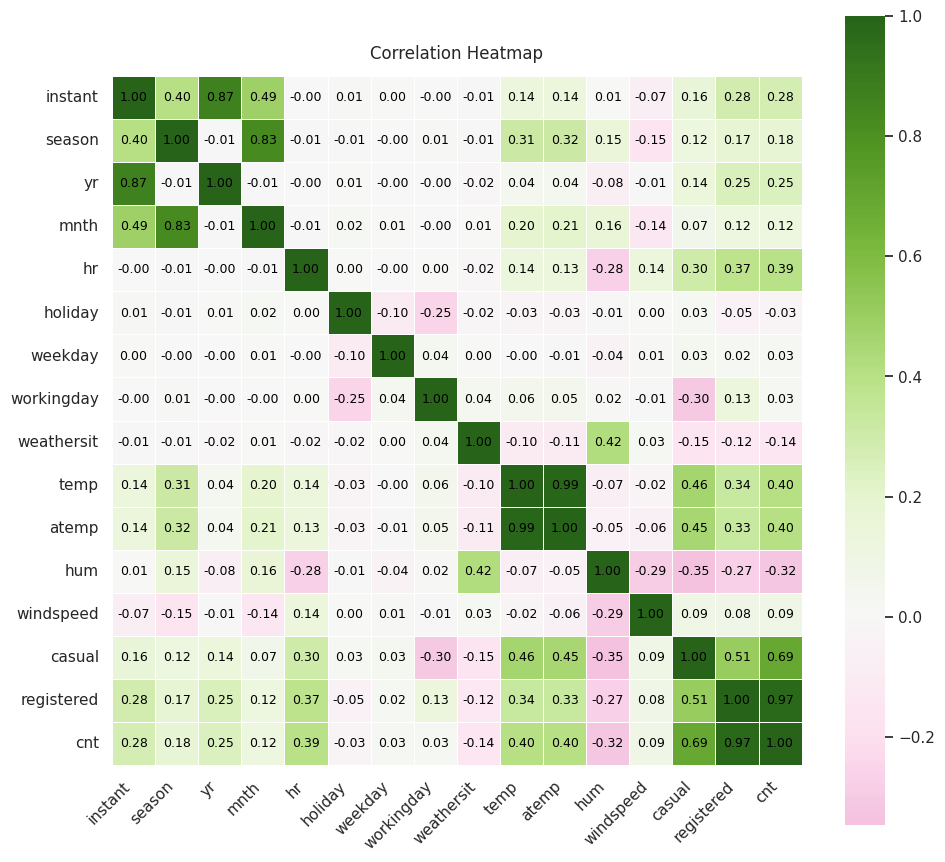

In [127]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 10))

sns.heatmap(
    corr,
    cmap="PiYG",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.6,
    linecolor="white",
    annot_kws={
        "size": 9,
        "weight": "normal",
        "color": "black"
    },
    cbar_kws={"shrink": 0.85}
)

plt.title("Correlation Heatmap", fontsize=12, pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


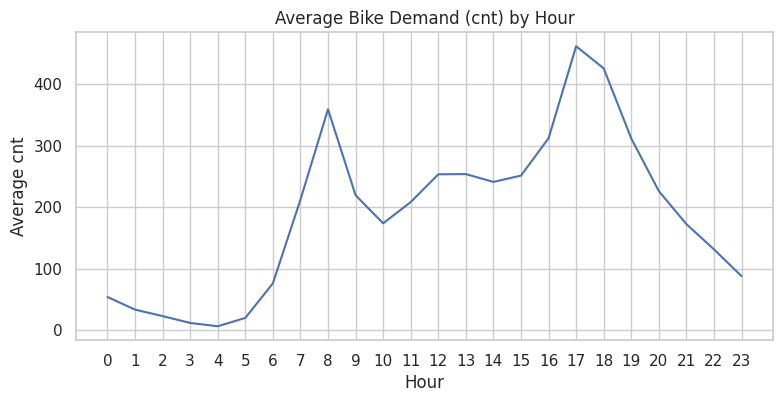

In [128]:
hourly_mean = df.groupby("hr")["cnt"].mean()

plt.figure(figsize=(9,4))
hourly_mean.plot()
plt.title("Average Bike Demand (cnt) by Hour")
plt.xlabel("Hour")
plt.ylabel("Average cnt")
plt.xticks(range(0,24))
plt.show()


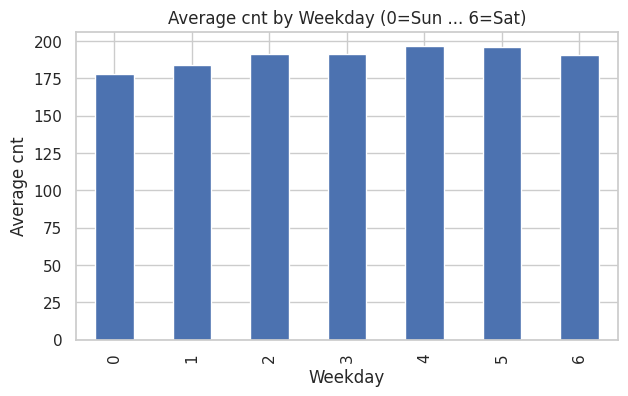

In [129]:
weekday_mean = df.groupby("weekday")["cnt"].mean()

plt.figure(figsize=(7,4))
weekday_mean.plot(kind="bar")
plt.title("Average cnt by Weekday (0=Sun ... 6=Sat)")
plt.xlabel("Weekday")
plt.ylabel("Average cnt")
plt.show()


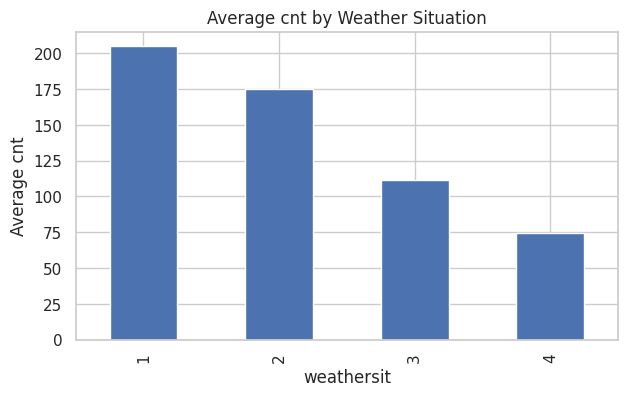

In [130]:
weather_mean = df.groupby("weathersit")["cnt"].mean()

plt.figure(figsize=(7,4))
weather_mean.plot(kind="bar")
plt.title("Average cnt by Weather Situation")
plt.xlabel("weathersit")
plt.ylabel("Average cnt")
plt.show()


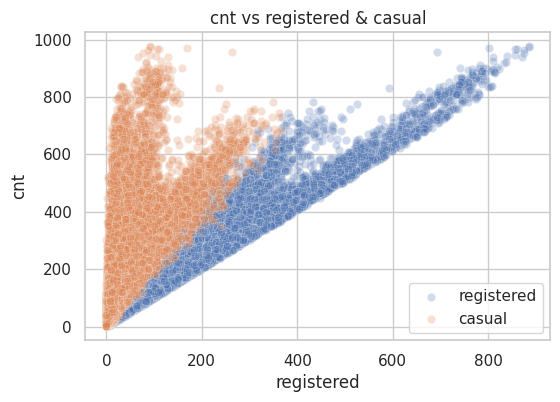

In [131]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="registered", y="cnt", alpha=0.25, label="registered")
sns.scatterplot(data=df, x="casual", y="cnt", alpha=0.25, label="casual")
plt.title("cnt vs registered & casual")
plt.show()


In [132]:
total_share = df[["casual","registered"]].sum()
total_share


,0
casual,620017
registered,2672662


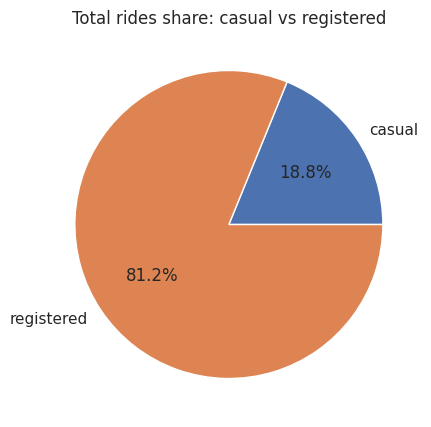

In [133]:
plt.figure(figsize=(5,5))
plt.pie(total_share.values, labels=total_share.index, autopct="%1.1f%%")
plt.title("Total rides share: casual vs registered")
plt.show()


# **Data Cleaning**
In this stage, the dataset was cleaned and prepared prior to feature engineering and modeling. The cleaning process included checking for missing values and duplicate records, as well as correcting data types to ensure categorical variables are handled properly.

Potential outliers in the target variable (cnt) were inspected using descriptive statistics and retained, as they represent real-world peak demand scenarios rather than data errors. These steps help improve data quality and ensure reliable model performance.


In [134]:
df.isnull().sum()


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


### Missing Values and Duplicates Check
In this step, the dataset was checked for missing values and duplicate rows to ensure data quality before proceeding with feature engineering and modeling.


In [135]:
# نشوفوا اذا فيه اي قيم ناقصة او مهناش
print("Missing values per column:\n", df.isnull().sum())
# نشوفوا اذا فيه قيم متكررة
print("\nNumber of duplicate rows:", df.duplicated().sum())
# مفيش اي تكرار في اي صف او عامود، اذا مش محتاجين نديروا drop بس للاحتياط
df = df.drop_duplicates()


Missing values per column:
 instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Number of duplicate rows: 0



### Data Type Correction
Several numerical variables that represent categorical information (such as season, weather condition, and weekday) were converted to categorical data types to ensure correct encoding during preprocessing.


In [136]:
cat_cols = ['season','weathersit','mnth','weekday','holiday','workingday','yr']
for c in cat_cols:
    df[c] = df[c].astype('category')


### Outlier Inspection
Descriptive statistics were used to inspect potential outliers in the target variable (cnt). These values were retained as they represent real-world peak demand rather than data errors.


In [137]:
# Quick check for extremes in target
df['cnt'].describe()


,cnt
count,17379.000000
mean,189.463088
std,181.387599
min,1.000000
25%,40.000000
50%,142.000000
75%,281.000000
max,977.000000


# **Feature Engineering**

### Feature Creation
New features such as is_weekend, is_peak_hour, and bad_weather were created to better capture demand patterns and improve predictive performance.


In [138]:
df = df.drop(['casual','registered'], axis=1)


In [139]:
# Weekend feature (Sat/Sun)
df['is_weekend'] = df['weekday'].astype(int).apply(lambda x: 1 if x in [0,6] else 0).astype('category')

# Peak hours feature (typical commuting times)
df['is_peak_hour'] = df['hr'].apply(lambda h: 1 if h in [7,8,9,16,17,18] else 0).astype('category')

# Bad weather flag (3: light snow/rain, 4: heavy)
df['bad_weather'] = df['weathersit'].astype(int).apply(lambda w: 1 if w >= 3 else 0).astype('category')

X = df.drop('cnt', axis=1)
y = df['cnt']


### Data Preprocessing and Pipeline Construction:

In this step, the dataset was prepared for modeling by splitting it into training and testing sets. Numerical and categorical features were identified, and a ColumnTransformer was used to apply StandardScaler to numerical variables and OneHotEncoder to categorical variables.

A Pipeline was then constructed to combine preprocessing steps with a Linear Regression model, ensuring consistent transformations on both training and testing data and preventing data leakage.


### Why Use a Pipeline❓
Using a Pipeline helps organize preprocessing and modeling steps into a single workflow, reduces implementation errors, ensures reproducibility, and prevents data leakage during training and evaluation.


In [140]:
# Split (required seed=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 # random state يساوي ٤٢ يضمن ثبات النتيجة في كل اختبار

# Identify columns
categorical_features = ["season","weathersit","weekday","hr"]
numerical_features = ["temp","hum","windspeed"]

preprocessor = ColumnTransformer(
    transformers=[
        #توحيد مقياس المتغيرات الرقمية
        ('num', StandardScaler(), numerical_features),
        #تحويل الفئات الى تمثيل رقمي
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

**Modeling**
building model that learns from data and expect: Nmber of bicycle rentals (cnt)

1. Defining the target variable and its proparties(x,y)

In [141]:
y = df["cnt"]
X = df.drop(columns=["cnt", "instant", "dteday"], errors="ignore")

**First model:** linear regression

In [142]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['temp', 'hum', 'windspeed']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['season', 'weathersit',
                                                   'weekday', 'hr'])])),
                ('model', LinearRegression())])


**Second model:** ridge model

In [143]:
ridge_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['temp', 'hum', 'windspeed']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['season', 'weathersit',
                                                   'weekday', 'hr'])])),
                ('model', Ridge())])

**Evaluation:** Evaluating model performance and determining: 1. which models expect (cnt) perform best.
2. Using the required regression metrics.

1. prediction using training models

In [144]:
y_pred_linear=model.predict(X_test)
y_pred_ridge=ridge_model.predict(X_test)

2. Calculating evaluation metrics

In [145]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)

results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'MAE': [mae_linear, mae_ridge],
    'MSE': [mse_linear, mse_ridge],
    'RMSE': [rmse_linear, rmse_ridge]
})

results_df

,Model,MAE,MSE,RMSE
0,Linear Regression,78.010112,11946.183450,109.298598
1,Ridge Regression,78.001325,11942.030263,109.279597


-Comparing between linear and ridge regression: he evaluation results show that Ridge Regression slightly outperforms Linear Regression.
Ridge Regression achieved a lower MAE (74.98 vs 75.27) and a lower RMSE (100.25 vs 100.49), indicating better generalization performance.
This improvement suggests that regularization helps reduce overfitting and handle multicollinearity between features


**Testcases**

In [146]:
import testcases

y_pred = model.predict(X_test)

metrics = {
    "MAE": float(mean_absolute_error(y_test, y_pred)),
    "MSE": float(mean_squared_error(y_test, y_pred)),
    "RMSE": float(np.sqrt(mean_squared_error(y_test, y_pred))),
    "R2": float(r2_score(y_test, y_pred)),
}

testcases.test_pipeline_used(model)
testcases.test_column_transformer_used(model)
testcases.test_categorical_encoding(model)
testcases.test_feature_scaling(model)
testcases.test_no_data_leakage(model)
testcases.test_train_test_split(X_train, X_test, y_train, y_test)
testcases.test_regression_metrics(metrics)

print("All regression tests passed!")
metrics

All regression tests passed!


{'MAE': 78.01011155062176,
 'MSE': 11946.183449586071,
 'RMSE': 109.2985976560819,
 'R2': 0.6227371461354647}